In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

In [16]:
data = pd.read_csv('../datasets/iris.csv')
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [46]:
# data
X = data.drop(['species'], axis=1)
y = data['species'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2})

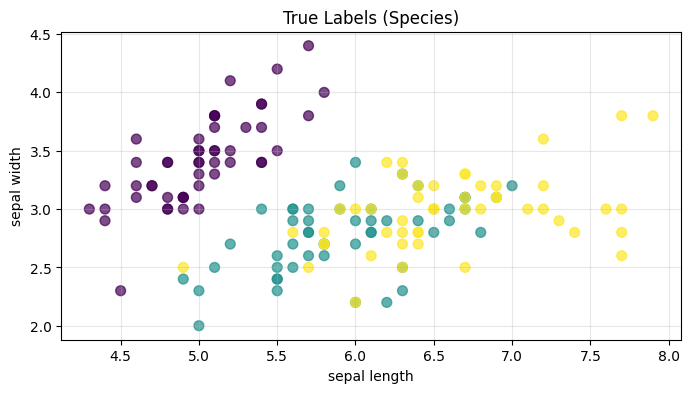

In [57]:
# plot
plt.figure(figsize=(8, 4))

plt.scatter(X["sepal_length"], X["sepal_width"], c=y, cmap='viridis', s=50, alpha=0.7)
plt.title('True Labels (Species)')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.grid(True, alpha=0.3)

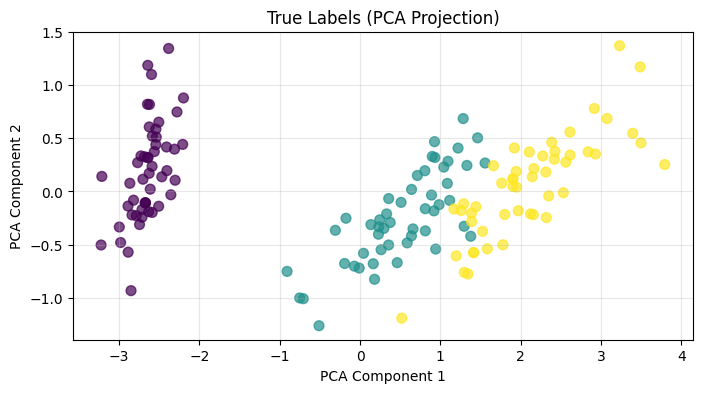

In [54]:
# using pca to see the result in 2D visualization (all 4 features)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 4))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
plt.title('True Labels (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)

In [67]:
feature_sets = {
    'All 4 Features': X,
    'Petal Features (2)': X[['petal_length', 'petal_width']],
    'Sepal Features (2)': X[['sepal_length', 'sepal_width']],
    'PCA (2 components)': X_pca
}

results = []

for name, data in feature_sets.items():
    # scale the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    # K-Means
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_scaled)
    
    # evaluation metrics
    silhouette = silhouette_score(data_scaled, labels)
    ari = adjusted_rand_score(y, labels)
    nmi = normalized_mutual_info_score(y, labels)
    
    results.append({
        'Features': name,
        'Silhouette': silhouette,
        'ARI': ari,
        'NMI': nmi
    })
    
    print(f"\n{name}:")
    print(f"  Silhouette Score: {silhouette:.4f}")
    print(f"  Adjusted Rand Index: {ari:.4f} (how well matches true labels)")
    print(f"  Normalized Mutual Info: {nmi:.4f} (how well matches true labels)")

# Create comparison table
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("FEATURE SET COMPARISON")
print("="*60)
print(results_df.round(4))


All 4 Features:
  Silhouette Score: 0.4590
  Adjusted Rand Index: 0.6201 (how well matches true labels)
  Normalized Mutual Info: 0.6595 (how well matches true labels)

Petal Features (2):
  Silhouette Score: 0.6736
  Adjusted Rand Index: 0.8857 (how well matches true labels)
  Normalized Mutual Info: 0.8642 (how well matches true labels)

Sepal Features (2):
  Silhouette Score: 0.4364
  Adjusted Rand Index: 0.5190 (how well matches true labels)
  Normalized Mutual Info: 0.5600 (how well matches true labels)

PCA (2 components):
  Silhouette Score: 0.5032
  Adjusted Rand Index: 0.5321 (how well matches true labels)
  Normalized Mutual Info: 0.5873 (how well matches true labels)

FEATURE SET COMPARISON
             Features  Silhouette     ARI     NMI
0      All 4 Features      0.4590  0.6201  0.6595
1  Petal Features (2)      0.6736  0.8857  0.8642
2  Sepal Features (2)      0.4364  0.5190  0.5600
3  PCA (2 components)      0.5032  0.5321  0.5873


In [72]:
#========================================================================================================
# LET'S TRY ON ALL PETAL FEATURES WHICH HAVE CLOSEST RESULT TO REAL LABELS (DEEP DIVE!):
#========================================================================================================

In [115]:
# scaling data
X_petal = X[['petal_length', 'petal_width']]
petal_scalar = StandardScaler()
X_petal_scaled = petal_scalar.fit_transform(X_petal)

In [89]:
print("\n" + "="*60)
print("FINDING OPTIMAL K")
print("="*60)

K_range = range(2, 8)
inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []
best_k, best_score = 1, 0

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_petal_scaled)

    inertias.append(kmeans_temp.inertia_) # Elbow
    silhouette_scores.append(silhouette_score(X_petal_scaled, labels_temp))
    calinski_scores.append(calinski_harabasz_score(X_petal_scaled, labels_temp))
    davies_scores.append(davies_bouldin_score(X_petal_scaled, labels_temp))

    best_k, best_score = (k, silhouette_scores[-1]) if silhouette_scores[-1] > best_score else (best_k, best_score)
    
    print(f"K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

print(f"\nChosen k: {best_k} with Silhouette={best_score:.4f}")


FINDING OPTIMAL K
K=2: Inertia=54.15, Silhouette=0.7432
K=3: Inertia=18.05, Silhouette=0.6736
K=4: Inertia=12.31, Silhouette=0.5983
K=5: Inertia=9.18, Silhouette=0.5729
K=6: Inertia=7.23, Silhouette=0.5802
K=7: Inertia=6.04, Silhouette=0.5759

Chosen k: 2 with Silhouette=0.7432


In [108]:
# test with 3!

# model
kmeans = KMeans(n_clusters=3, max_iter=10, random_state=42)
kmeans.fit_predict(X_petal_scaled)

# result 
labels = kmeans.labels_
centers = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers)

# metrics
inertia = kmeans.inertia_
silhouette_avg = silhouette_score(X_petal_scaled, labels)
ari_petal = adjusted_rand_score(y, labels)